In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading data for advanced visualization...")
df = pd.read_csv('deep_motor_training_data.csv')

# ==========================================
# 1. TERMINAL OVERVIEW (Data Profiling)
# ==========================================
print("\n" + "="*50)
print("⚙️ DATASET OVERVIEW ⚙️")
print("="*50)
print(f"Total Rows (Samples):     {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}")
print(f"Number of Classes:        {df['label'].nunique()}")

print("\n📊 Class Distribution:")
print(df['label'].value_counts())


Loading data for advanced visualization...

⚙️ DATASET OVERVIEW ⚙️
Total Rows (Samples):     640
Total Columns (Features): 1039
Number of Classes:        8

📊 Class Distribution:
label
voltage_unbalance    80
misalignment         80
unbalance            80
stator               80
healthy              80
bearing              80
rotor_bar            80
bowed                80
Name: count, dtype: int64


In [ ]:
# Dynamically find the summary statistics columns (ignoring the hundreds of FFT bins)
summary_cols = [col for col in df.columns if any(x in col for x in ['_rms', '_kurt', '_crest'])]

print(f"\n📈 Summary Statistic Features Identified ({len(summary_cols)} total):")
for col in summary_cols:
    print(f" - {col}")
print("="*50 + "\n")


📈 Summary Statistic Features Identified (12 total):
 - acc1_rms
 - acc1_kurt
 - acc1_crest
 - mic_rms
 - mic_kurt
 - mic_crest
 - acc2_rms
 - acc2_kurt
 - acc2_crest
 - acc3_axial_rms
 - acc3_axial_kurt
 - acc3_axial_crest



Generating visual dashboard. Close the plot window to continue...


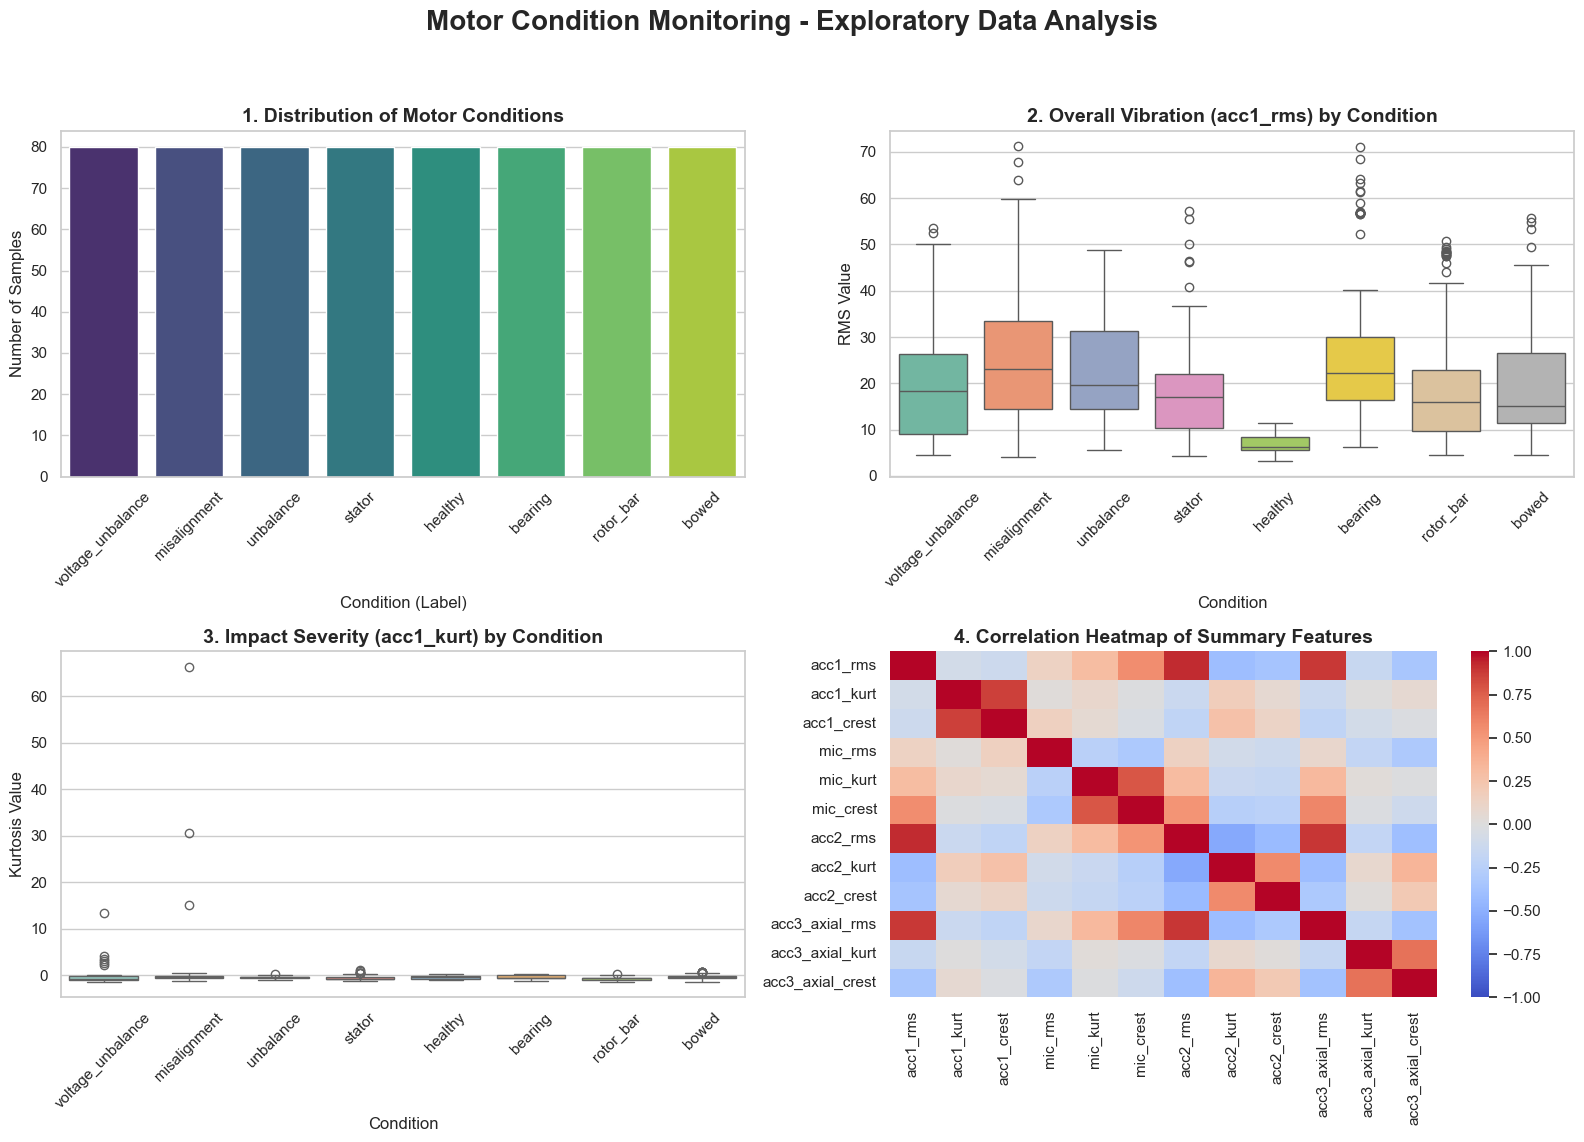

In [ ]:

# ==========================================
# 2. VISUAL DASHBOARD
# ==========================================
print("Generating visual dashboard. Close the plot window to continue...")

# Set up the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# --- Plot 1: Class Distribution ---
sns.countplot(
    data=df, 
    x='label', 
    order=df['label'].value_counts().index, 
    ax=axes[0, 0], 
    hue='label',
    palette='viridis',
    legend=False
)

axes[0, 0].set_title("1. Distribution of Motor Conditions", fontsize=14, weight='bold')
axes[0, 0].set_xlabel("Condition (Label)")
axes[0, 0].set_ylabel("Number of Samples")
axes[0, 0].tick_params(axis='x', rotation=45)

# --- Plot 2: RMS (Overall Vibration Energy) by Class ---
# RMS is a great indicator of general unbalance or looseness.
sns.boxplot(
    data=df, 
    x='label', 
    y='acc1_rms', 
    order=df['label'].value_counts().index, 
    ax=axes[0, 1], 
    hue='label',
    palette='Set2',
    legend=False
)
axes[0, 1].set_title("2. Overall Vibration (acc1_rms) by Condition", fontsize=14, weight='bold')
axes[0, 1].set_xlabel("Condition")
axes[0, 1].set_ylabel("RMS Value")
axes[0, 1].tick_params(axis='x', rotation=45)

# --- Plot 3: Kurtosis (Impact Spikes) by Class ---
# Kurtosis measures the "spikiness" of a signal. High kurtosis usually means bearing faults.
sns.boxplot(
    data=df, 
    x='label', 
    y='acc1_kurt', 
    order=df['label'].value_counts().index, 
    ax=axes[1, 0], 
    hue='label',
    palette='Set3',
    legend=False
)
axes[1, 0].set_title("3. Impact Severity (acc1_kurt) by Condition", fontsize=14, weight='bold')
axes[1, 0].set_xlabel("Condition")
axes[1, 0].set_ylabel("Kurtosis Value")
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Plot 4: Correlation Heatmap ---
# Shows how strongly the different summary features relate to one another
corr_matrix = df[summary_cols].corr()
sns.heatmap(
    corr_matrix, 
    annot=False, 
    cmap='coolwarm', 
    ax=axes[1, 1], 
    vmin=-1, 
    vmax=1
)
axes[1, 1].set_title("4. Correlation Heatmap of Summary Features", fontsize=14, weight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()